<div style="background-color:#1a1a2e; padding:20px; border-radius:10px;">
<h1 style="color:#00d4ff; text-align:center;">📊 STEP 1: Import Libraries</h1>
<h3 style="color:#ffffff; text-align:center;">Load Python Libraries for Data Analysis</h3>
<p style="color:#a8a8b3; text-align:center;">
pandas · numpy · matplotlib · seaborn
</p>
</div>

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">📊 Step 2 — Load Vancouver Housing Data</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Load and filter Vancouver properties from Kaggle dataset</p>
</div>

In [16]:
# Load the data and check columns
df_all = pd.read_csv('../data/raw/canada_housing/cleaned_canada.csv')

print("Column names:")
print(df_all.columns.tolist())

print("\nFirst few rows:")
print(df_all.head())

print("\nData shape:")
print(df_all.shape)

print("\nData info:")
print(df_all.info())

Column names:
['City', 'Province', 'Latitude', 'Longitude', 'Price', 'Bedrooms', 'Bathrooms', 'Acreage', 'Property Type', 'Square Footage', 'Garage', 'Parking', 'Basement', 'Exterior', 'Fireplace', 'Heating', 'Flooring', 'Roof', 'Waterfront', 'Sewer', 'Pool', 'Garden', 'Balcony']

First few rows:
           City Province   Latitude   Longitude      Price  Bedrooms  \
0    Revelstoke       BC  50.976585 -118.173149   839000.0       3.0   
1       Boswell       BC  49.471870 -116.770195  1150000.0       3.0   
2  West Kelowna       BC  49.825230 -119.603253   149000.0       2.0   
3       Kelowna       BC  49.821860 -119.480143  1298000.0       5.0   
4   Maple Ridge       BC  49.221673 -122.596637   759900.0       3.0   

   Bathrooms  Acreage  Property Type  Square Footage  ... Exterior Fireplace  \
0        2.0     0.00          Condo           891.0  ...      NaN        No   
1        2.0     0.32  Single Family          1881.0  ...      NaN        No   
2        1.0     0.00  Single

In [17]:
# Load the cleaned Canada housing dataset
df_all = pd.read_csv('../data/raw/canada_housing/cleaned_canada.csv')

# Filter to Vancouver only
df = df_all[df_all['City'] == 'Vancouver'].copy()

print(f"✅ Vancouver rows: {len(df)}")
print(f"\nFirst few rows:")
print(df.head())

print(f"\n📊 Dataset shape: {df.shape}")
print(f"\n📋 Column names:")
print(df.columns.tolist())

print(f"\n💰 Price range: ${df['Price'].min():,.0f} - ${df['Price'].max():,.0f}")
print(f"📊 Mean price: ${df['Price'].mean():,.0f}")
print(f"📊 Median price: ${df['Price'].median():,.0f}")

print(f"\n📍 Latitude range: {df['Latitude'].min()} - {df['Latitude'].max()}")
print(f"📍 Longitude range: {df['Longitude'].min()} - {df['Longitude'].max()}")

print(f"\n🛏️  Bedrooms range: {df['Bedrooms'].min()} - {df['Bedrooms'].max()}")
print(f"🚿 Bathrooms range: {df['Bathrooms'].min()} - {df['Bathrooms'].max()}")

✅ Vancouver rows: 3860

First few rows:
          City Province   Latitude   Longitude      Price  Bedrooms  \
15   Vancouver       BC  49.286844 -123.124152  1798000.0       2.0   
53   Vancouver       BC  49.215653 -123.116343   928000.0       2.0   
56   Vancouver       BC  49.215653 -123.116343   918000.0       2.0   
135  Vancouver       BC  49.277631 -123.122958   729000.0       1.0   
183  Vancouver       BC  49.275778 -123.125761   899000.0       1.0   

     Bathrooms  Acreage Property Type  Square Footage  ... Exterior Fireplace  \
15         3.0      0.0         Condo          1183.0  ...      NaN        No   
53         2.0      0.0         Condo           884.0  ...      NaN        No   
56         2.0      0.0         Condo           815.0  ...      NaN        No   
135        1.0      0.0         Condo           708.0  ...      NaN        No   
183        1.0      0.0         Condo           862.0  ...      NaN       Yes   

        Heating Flooring Roof Waterfront Sewer

<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">🔍 Step 3 — Check Missing Values</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Identify which features have missing data</p>
</div>

In [18]:
# Check for missing values
print("Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0])

print(f"\n📊 Total missing values: {df.isnull().sum().sum()}")
print(f"📊 Missing percentage:\n")
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
print(missing_pct[missing_pct > 0].sort_values(ascending=False))

Missing values per column:
Basement    3845
Exterior    3860
Heating      485
Flooring    3860
Roof        3860
dtype: int64

📊 Total missing values: 15910
📊 Missing percentage:

Exterior    100.00
Roof        100.00
Flooring    100.00
Basement     99.61
Heating      12.56
dtype: float64


<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">📈 Step 4 — Price Distribution & Correlations</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Visualize price distribution and feature relationships</p>
</div>

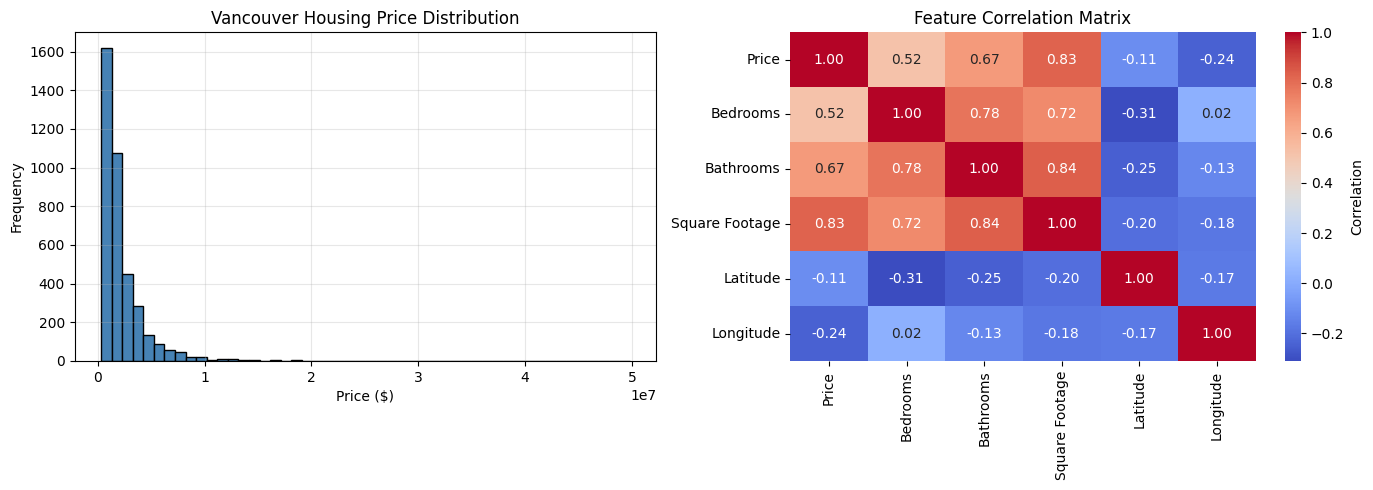

✅ Visualizations saved to outputs/figures/01_eda_visualizations.png


In [19]:
# Select numeric columns for analysis
numeric_cols = ['Price', 'Bedrooms', 'Bathrooms', 'Square Footage', 'Latitude', 'Longitude']
df_numeric = df[numeric_cols].dropna()

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Price Distribution Histogram
axes[0].hist(df['Price'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Vancouver Housing Price Distribution')
axes[0].grid(alpha=0.3)

# 2. Correlation Heatmap
corr_matrix = df_numeric.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('../outputs/figures/01_eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualizations saved to outputs/figures/01_eda_visualizations.png")

<div style="background-color:#0f3460; padding:15px; border-radius:10px; border-left:6px solid #e94560;">
<h2 style="color:#ffffff; margin:0;">🧹 Step 5 — Clean Data for Modeling</h2>
<p style="color:#a8d8ea; margin:5px 0 0 0;">Remove columns with >95% missing, keep useful features</p>
</div>

In [20]:
# Drop columns with >95% missing values
columns_to_drop = ['Exterior', 'Roof', 'Flooring', 'Basement']
df_clean = df.drop(columns=columns_to_drop)

print(f"Dropped columns: {columns_to_drop}")
print(f"\n✅ Dataset shape after dropping useless columns: {df_clean.shape}")

# Select features for modeling
feature_cols = ['Bedrooms', 'Bathrooms', 'Square Footage', 'Latitude', 'Longitude', 
                'Acreage', 'Garage', 'Parking', 'Fireplace', 'Heating', 'Waterfront', 
                'Sewer', 'Pool', 'Garden', 'Balcony']

# Keep only relevant columns
df_model = df_clean[['Price'] + feature_cols].copy()

# Remove rows with ANY missing values
df_model = df_model.dropna()

print(f"\n✅ Final dataset shape for modeling: {df_model.shape}")
print(f"📊 Rows removed: {len(df_clean) - len(df_model)}")
print(f"\n✅ Ready for modeling!")

Dropped columns: ['Exterior', 'Roof', 'Flooring', 'Basement']

✅ Dataset shape after dropping useless columns: (3860, 19)

✅ Final dataset shape for modeling: (3375, 16)
📊 Rows removed: 485

✅ Ready for modeling!


In [21]:
# Save the cleaned data for next notebooks
df_model.to_csv('../data/processed/vancouver_housing_cleaned.csv', index=False)

print("✅ Cleaned data saved!")
print(f"📁 Location: ../data/processed/vancouver_housing_cleaned.csv")
print(f"📊 Shape: {df_model.shape}")
print(f"📋 Columns: {df_model.columns.tolist()}")

✅ Cleaned data saved!
📁 Location: ../data/processed/vancouver_housing_cleaned.csv
📊 Shape: (3375, 16)
📋 Columns: ['Price', 'Bedrooms', 'Bathrooms', 'Square Footage', 'Latitude', 'Longitude', 'Acreage', 'Garage', 'Parking', 'Fireplace', 'Heating', 'Waterfront', 'Sewer', 'Pool', 'Garden', 'Balcony']
